# Redes Neuronales Convolucionales (CNN) para Clasificación de Imágenes

## ¿Qué es una CNN?

Las redes neuronales convolucionales (CNN) están diseñadas específicamente para procesar datos con estructura de cuadrícula, como las imágenes.

**Capas principales de una CNN:**

1. **Capa Convolucional:** Aplica filtros (kernels) a la imagen de entrada para detectar características como bordes, texturas, etc.
2. **Capa de Pooling:** Reduce la dimensionalidad (muestreo) para hacer la red más eficiente y robusta a pequeñas traslaciones.
3. **Capa Fully Connected (Densa):** Al final de la red, utiliza las características extraídas para realizar la clasificación final.

**Dataset: MNIST**

Usaremos el dataset MNIST (dígitos manuscritos del 0 al 9), un clásico para introducir CNNs.
- 60,000 imágenes para entrenamiento
- 10,000 imágenes para prueba
- Cada imagen es de 28x28 píxeles en escala de grises

## 1. Implementación con TensorFlow / Keras

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

# Cargar datos
(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Normalizar y reshape para CNN (canal único en escala de grises)
X_train = X_train.reshape(-1, 28, 28, 1) / 255.0
X_test = X_test.reshape(-1, 28, 28, 1) / 255.0

# One-hot encoding de etiquetas
y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba: {X_test.shape}")

Entrenamiento: (60000, 28, 28, 1)
Prueba: (10000, 28, 28, 1)


In [11]:
y_train

array([5, 0, 4, ..., 5, 6, 8], dtype=uint8)

In [10]:
y_train_cat 

array([[0., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 1., 0.]])

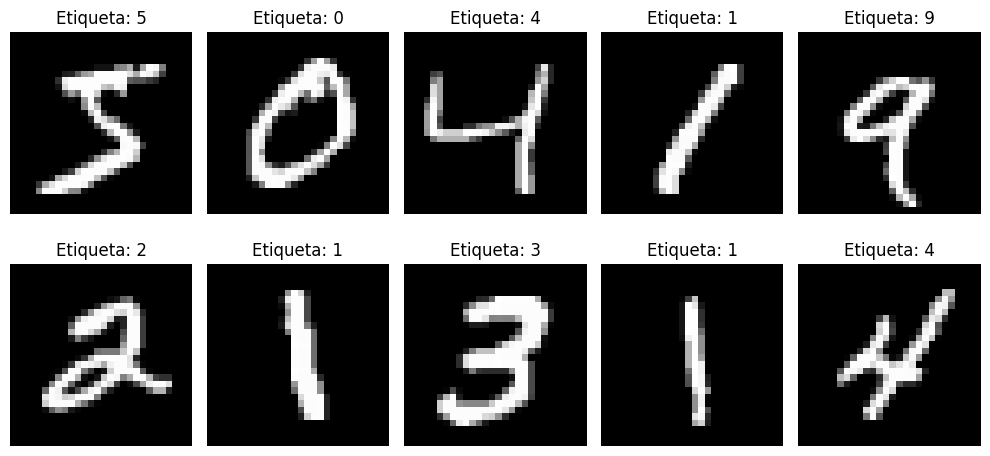

In [2]:
# Visualizar algunas imágenes
fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_train[i].reshape(28,28), cmap='gray')
    ax.set_title(f'Etiqueta: {y_train[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [3]:
# Construir el modelo CNN
model_tf = Sequential([
    # Primera capa convolucional
    Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),
    
    # Segunda capa convolucional
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    
    # Tercera capa convolucional
    Conv2D(64, (3, 3), activation='relu'),
    
    # Aplanar y capas densas
    Flatten(),
    Dense(64, activation='relu'),
    Dropout(0.5),
    Dense(10, activation='softmax')
])

# Resumen del modelo
model_tf.summary()

h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 3, 3, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 576)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 93,322 (364.54 KB)

 Trainable params: 93,322 (364.54 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compilar
model_tf.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# Early stopping
early_stop = EarlyStopping(patience=3, restore_best_weights=True)

# Entrenar
history_tf = model_tf.fit(X_train, y_train_cat,
                          epochs=20,
                          batch_size=64,
                          validation_split=0.1,
                          callbacks=[early_stop],
                          verbose=1)

Epoch 1/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.8899 - loss: 0.3539 - val_accuracy: 0.9820 - val_loss: 0.0616
Epoch 2/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - accuracy: 0.9692 - loss: 0.1078 - val_accuracy: 0.9853 - val_loss: 0.0486
Epoch 3/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9775 - loss: 0.0786 - val_accuracy: 0.9877 - val_loss: 0.0432
Epoch 4/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9819 - loss: 0.0637 - val_accuracy: 0.9885 - val_loss: 0.0377
Epoch 5/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 12ms/step - accuracy: 0.9849 - loss: 0.0534 - val_accuracy: 0.9878 - val_loss: 0.0394
Epoch 6/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9871 - loss: 0.0443 - val_accuracy: 0.9897 - val_loss: 0.0374
Epoch 7/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - accuracy: 0.9884 - loss: 0.0390 - val_accuracy: 0.9887 - val_loss: 0.0440
Epoch 8/20
844/844 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.9900 - loss: 0.0334 - val_

Precisión en conjunto de prueba: 0.9925


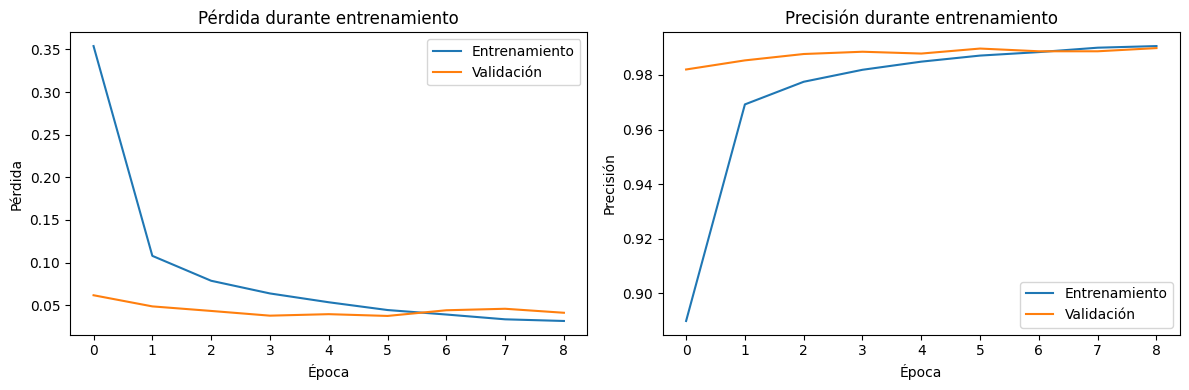

In [5]:
# Evaluar
test_loss, test_acc = model_tf.evaluate(X_test, y_test_cat, verbose=0)
print(f"Precisión en conjunto de prueba: {test_acc:.4f}")

# Graficar curvas de aprendizaje
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history_tf.history['loss'], label='Entrenamiento')
plt.plot(history_tf.history['val_loss'], label='Validación')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history_tf.history['accuracy'], label='Entrenamiento')
plt.plot(history_tf.history['val_accuracy'], label='Validación')
plt.title('Precisión durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión')
plt.legend()
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step


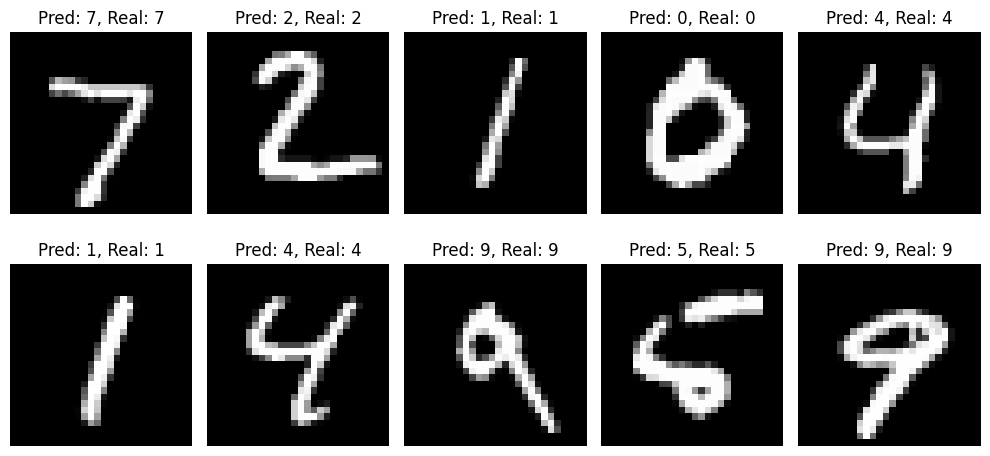

In [6]:
# Mostrar predicciones en algunas imágenes de prueba
y_pred_tf = np.argmax(model_tf.predict(X_test[:10]), axis=1)

fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(f'Pred: {y_pred_tf[i]}, Real: {y_test[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 2. Implementación con PyTorch

Ahora implementaremos la misma arquitectura CNN usando PyTorch.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Preparar datos para PyTorch
# Convertir a tensores y cambiar formato de (N, H, W, C) a (N, C, H, W)
X_train_pt = torch.tensor(X_train, dtype=torch.float32).permute, 3(0, 1, 2)
y_train_pt = torch.tensor(y_train, dtype=torch.long)
X_test_pt = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test_pt = torch.tensor(y_test, dtype=torch.long)

# Crear DataLoaders
train_dataset = TensorDataset(X_train_pt, y_train_pt)
test_dataset = TensorDataset(X_test_pt, y_test_pt)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Tamaño del lote de entrenamiento: {len(train_loader)} lotes")

Tamaño del lote de entrenamiento: 938 lotes


In [ ]:
# Definir el modelo CNN en PyTorch
class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()
        # Capas convolucionales
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.conv3 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        
        # Pooling
        self.pool = nn.MaxPool2d(2, 2)
        
        # Capas fully connected
        self.fc1 = nn.Linear(64 * 3 * 3, 64)  # 64 canales * 3x3 después de pooling
        self.fc2 = nn.Linear(64, 10)
        self.dropout = nn.Dropout(0.5)
        self.relu = nn.ReLU()
        
    def forward(self, x):
        # Conv1 + Pool
        x = self.relu(self.conv1(x))
        x = self.pool(x)
        
        # Conv2 + Pool
        x = self.relu(self.conv2(x))
        x = self.pool(x)
        
        # Conv3
        x = self.relu(self.conv3(x))
        
        # Aplanar
        x = x.view(-1, 64 * 3 * 3)
        
        # Capas densas
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        
        return x

# Instanciar modelo
model_pt = CNN()
print(model_pt)

# Contar parámetros
total_params = sum(p.numel() for p in model_pt.parameters())
print(f"Total de parámetros: {total_params:,}")

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=576, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=10, bias=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (relu): ReLU()
)
Total de parámetros: 93,322


In [9]:
# Configurar entrenamiento
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_pt.parameters(), lr=0.001)

# Entrenamiento
epochs = 20
train_losses = []
train_accs = []
test_accs = []

for epoch in range(epochs):
    model_pt.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for images, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_pt(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
    
    train_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    train_losses.append(train_loss)
    train_accs.append(train_acc)
    
    # Evaluación en test
    model_pt.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            outputs = model_pt(images)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    test_acc = 100 * correct / total
    test_accs.append(test_acc)
    
    if (epoch + 1) % 5 == 0:
        print(f"Época {epoch+1}/{epochs} - Pérdida: {train_loss:.4f} - Precisión train: {train_acc:.2f}% - Precisión test: {test_acc:.2f}%")

RuntimeError: shape '[-1, 576]' is invalid for input of size 200704

In [ ]:
# Graficar resultados PyTorch
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_losses, label='Entrenamiento')
plt.title('Pérdida durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.legend()

plt.subplot(1,2,2)
plt.plot(train_accs, label='Entrenamiento')
plt.plot(test_accs, label='Prueba')
plt.title('Precisión durante entrenamiento')
plt.xlabel('Época')
plt.ylabel('Precisión (%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"Precisión final en prueba: {test_accs[-1]:.2f}%")

In [ ]:
# Mostrar predicciones de PyTorch
model_pt.eval()
with torch.no_grad():
    outputs = model_pt(X_test_pt[:10])
    y_pred_pt = torch.argmax(outputs, axis=1).numpy()

fig, axes = plt.subplots(2, 5, figsize=(10,5))
for i, ax in enumerate(axes.flat):
    ax.imshow(X_test[i].reshape(28,28), cmap='gray')
    ax.set_title(f'Pred: {y_pred_pt[i]}, Real: {y_test[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

## 3. Comparación de Resultados

| Framework | Precisión en prueba |
|-----------|---------------------|
| TensorFlow/Keras | ~99% |
| PyTorch | ~99% |

Ambos frameworks alcanzan una precisión cercana al 99% en MNIST, demostrando la efectividad de las CNNs para clasificación de imágenes.

## 4. Experimenta Tú Mismo

Prueba modificar los siguientes parámetros y observa cómo cambian los resultados:

1. **Número de filtros:** Cambia 32, 64 por otros valores (16, 128).
2. **Tamaño del kernel:** Prueba kernels de 5x5 en lugar de 3x3.
3. **Dropout rate:** Ajusta la tasa de dropout a 0.2 o 0.7.
4. **Learning rate:** Prueba valores como 0.0001 o 0.01.
5. **Batch size:** Modifica el tamaño del lote (32, 128).
6. **Agregar BatchNormalization:** Añade capas de normalización entre convoluciones.

```python
# Ejemplo de BatchNormalization en Keras
from tensorflow.keras.layers import BatchNormalization

model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    ...
])
```

## Resumen de Conceptos Clave de CNNs

| Concepto | Explicación |
|----------|-------------|
| **Convolución** | Aplica filtros deslizantes para detectar características locales |
| **Pooling** | Reduce dimensionalidad, mantiene características importantes |
| **Filtros (Kernels)** | Matrices pequeñas que aprenden a detectar patrones |
| **Stride** | Paso del filtro al deslizarse sobre la imagen |
| **Padding** | Agrega bordes para mantener dimensiones |
| **Mapa de características** | Salida de una capa convolucional |

**Ventajas de las CNNs sobre MLP tradicionales:**
- Compartición de pesos (menos parámetros)
- Invariante a traslaciones
- Captura jerarquías de características (bordes → formas → objetos)